## Assignment - 1 CS626

### Imports

In [ ]:
import nltk
from nltk.corpus import brown
from numpy.linalg import norm
import pandas as pd
import numpy as np
import matplotlib.pylab as pl
import seaborn as sns
import copy

In [ ]:
nltk.download('brown')
nltk.download('universal_tagset')

[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package universal_tagset to /root/nltk_data...
[nltk_data]   Unzipping taggers/universal_tagset.zip.


True

### Pre-processing

In [ ]:
# get statements 
statements_tags = brown.tagged_sents(tagset="universal")

In [ ]:
print(len(statements_tags))
print(statements_tags[0])

57340
[('The', 'DET'), ('Fulton', 'NOUN'), ('County', 'NOUN'), ('Grand', 'ADJ'), ('Jury', 'NOUN'), ('said', 'VERB'), ('Friday', 'NOUN'), ('an', 'DET'), ('investigation', 'NOUN'), ('of', 'ADP'), ("Atlanta's", 'NOUN'), ('recent', 'ADJ'), ('primary', 'NOUN'), ('election', 'NOUN'), ('produced', 'VERB'), ('``', '.'), ('no', 'DET'), ('evidence', 'NOUN'), ("''", '.'), ('that', 'ADP'), ('any', 'DET'), ('irregularities', 'NOUN'), ('took', 'VERB'), ('place', 'NOUN'), ('.', '.')]


In [ ]:
data = []
for s in range(len(statements_tags)):
  g = []
  for word_tag in range(len(statements_tags[s])):
    g.append([statements_tags[s][word_tag][0].lower(), statements_tags[s][word_tag][1]])
  data.append(g)
print(data[0])

[['the', 'DET'], ['fulton', 'NOUN'], ['county', 'NOUN'], ['grand', 'ADJ'], ['jury', 'NOUN'], ['said', 'VERB'], ['friday', 'NOUN'], ['an', 'DET'], ['investigation', 'NOUN'], ['of', 'ADP'], ["atlanta's", 'NOUN'], ['recent', 'ADJ'], ['primary', 'NOUN'], ['election', 'NOUN'], ['produced', 'VERB'], ['``', '.'], ['no', 'DET'], ['evidence', 'NOUN'], ["''", '.'], ['that', 'ADP'], ['any', 'DET'], ['irregularities', 'NOUN'], ['took', 'VERB'], ['place', 'NOUN'], ['.', '.']]


In [ ]:
# print tagset
tagged_words=[tup for sent in data for tup in sent]
tags=set([tag for word,tag in tagged_words])
print(tags)

{'VERB', 'PRT', 'CONJ', 'ADJ', 'ADP', 'NUM', 'PRON', '.', 'X', 'NOUN', 'DET', 'ADV'}


### Split Train and Test Data

In [ ]:
frac = 0.8 
np.random.seed(0)
train_sz = int(frac * len(data))
indices_train = np.ones((train_sz,), dtype = int)
indices_train = np.append(indices_train, np.zeros((len(data)-train_sz,), dtype = int))
np.random.shuffle(indices_train)

In [ ]:
train_data = []
test_data = []
for ind in range(len(indices_train)):
  if indices_train[ind] == 1:
    train_data.append(data[ind])
  else:
    test_data.append(data[ind])

In [ ]:
print(len(train_data), len(test_data))
print(train_data[1])
print(train_data[0])

words_0_train = set([w[0] for w in train_data[0]])
print(len(words_0_train))

45872 11468
[['the', 'DET'], ['jury', 'NOUN'], ['further', 'ADV'], ['said', 'VERB'], ['in', 'ADP'], ['term-end', 'NOUN'], ['presentments', 'NOUN'], ['that', 'ADP'], ['the', 'DET'], ['city', 'NOUN'], ['executive', 'ADJ'], ['committee', 'NOUN'], [',', '.'], ['which', 'DET'], ['had', 'VERB'], ['over-all', 'ADJ'], ['charge', 'NOUN'], ['of', 'ADP'], ['the', 'DET'], ['election', 'NOUN'], [',', '.'], ['``', '.'], ['deserves', 'VERB'], ['the', 'DET'], ['praise', 'NOUN'], ['and', 'CONJ'], ['thanks', 'NOUN'], ['of', 'ADP'], ['the', 'DET'], ['city', 'NOUN'], ['of', 'ADP'], ['atlanta', 'NOUN'], ["''", '.'], ['for', 'ADP'], ['the', 'DET'], ['manner', 'NOUN'], ['in', 'ADP'], ['which', 'DET'], ['the', 'DET'], ['election', 'NOUN'], ['was', 'VERB'], ['conducted', 'VERB'], ['.', '.']]
[['the', 'DET'], ['fulton', 'NOUN'], ['county', 'NOUN'], ['grand', 'ADJ'], ['jury', 'NOUN'], ['said', 'VERB'], ['friday', 'NOUN'], ['an', 'DET'], ['investigation', 'NOUN'], ['of', 'ADP'], ["atlanta's", 'NOUN'], ['recent', 

### Finding no. of unknown words

In [ ]:
tagged_words_train = [tup for sent in train_data for tup in sent]
words_train=set([word[0] for word in tagged_words_train])
print("No. of distinct words in train data: ",len(words_train))   #no. of distinct words in train data

tagged_words_test=[tup for sent in test_data for tup in sent]
words_test=set([word for word,tag in tagged_words_test])
print("No. of distinct words in test data: ",len(words_test))  #no. of distinct words in test data

count=0
for word in words_test:
  if word not in words_train:
    count+=1
print("No. of distinct unknown words in test data: ",count)   #no. of unknown words in test data
 

No. of distinct words in train data:  45105
No. of distinct words in test data:  22833
No. of distinct unknown words in test data:  4710


### Emission Probability

In [ ]:
### emission probability
word_tag_pairs = []
for t in train_data:
  for j in t:
    word_tag_pairs.append(j)
pairs_df = pd.DataFrame(word_tag_pairs, columns = ["word", "tag"])
print(pairs_df)

              word   tag
0              the   DET
1           fulton  NOUN
2           county  NOUN
3            grand   ADJ
4             jury  NOUN
...            ...   ...
931074      boucle  NOUN
931075       dress  NOUN
931076         was  VERB
931077  stupefying  VERB
931078           .     .

[931079 rows x 2 columns]


In [ ]:
count_pairs_df = pairs_df.groupby(pairs_df.columns.tolist(),as_index=False).size()
print(count_pairs_df)

              word   tag  size
0                !     .  1286
1            $.027  NOUN     2
2             $.03  NOUN     2
3        $.054/mbf  NOUN     1
4             $.07  NOUN     2
...            ...   ...   ...
48458  zubkovskaya  NOUN     1
48459      zurcher  NOUN     1
48460       zurich  NOUN     1
48461     zworykin  NOUN     1
48462        {0,t}  NOUN     1

[48463 rows x 3 columns]


In [ ]:
tags_df = pairs_df.groupby(['tag'],as_index=False).size()
tags_df = tags_df.set_index("tag")
# high=tags_df.head(12).sort_values("size", ascending=False)[tags_df.columns[0]].index[0]
total=tags_df.sum()
unknown={}
for index, row in tags_df.head(12).iterrows():
  unknown[index]=row['size']/total
print(unknown["ADJ"][0])
print(tags_df.head(12))

0.07201000129956749
        size
tag         
.     118147
ADJ    67047
ADP   116218
ADV    45032
CONJ   30594
DET   109773
NOUN  220690
NUM    11965
PRON   39774
PRT    23926
VERB  146771
X       1142


In [ ]:
em_prob = {}
for index, row in count_pairs_df.iterrows():
  prob = row["size"]/(tags_df.loc[row["tag"]]["size"])
  em_prob[row["word"], row["tag"]] = prob
  if index % 10000 == 0:
    print(index)


0
10000
20000
30000
40000


In [ ]:
e = {}
for x in em_prob:
  for state in tags:
    if (x[0], state) not in em_prob:
      e[x[0], state] = 0
    else:
      e[x[0], state] = em_prob[x[0], state]

In [ ]:
print(len(e), len(count_pairs_df))   #len(e) is no. of tag * no. of words in dataframe
print(e['if', 'VERB'])

541260 48463
0


### Transition Probability

In [ ]:
tag_tag_pairs = []
for t in train_data:
  for p in range(len(t)-1):
    tag_tag_pairs.append([t[p][1], t[p+1][1]])
tag_tag_df = pd.DataFrame(tag_tag_pairs, columns = ["tag", "next_tag"])
# print(tag_tag_df)

In [ ]:
count_tags_df = tag_tag_df.groupby(tag_tag_df.columns.tolist(),as_index=False).size()

In [ ]:
print(count_tags_df.head(15))

    tag next_tag   size
0     .        .  12649
1     .      ADJ   3383
2     .      ADP   7683
3     .      ADV   5123
4     .     CONJ   8236
5     .      DET   7932
6     .     NOUN   9839
7     .      NUM   1420
8     .     PRON   5565
9     .      PRT   2158
10    .     VERB   9053
11    .        X    161
12  ADJ        .   6717
13  ADJ      ADJ   3839
14  ADJ      ADP   5885


In [ ]:
total_tags_df = tag_tag_df.groupby(["tag"],as_index=False).size()
total_tags_df = total_tags_df.set_index("tag")

In [ ]:
trans_prob = {}
for index, row in count_tags_df.iterrows():
  
  prob = row["size"]/(total_tags_df.loc[row["tag"]]["size"])
  trans_prob[row["tag"], row["next_tag"]] = prob
  if index % 1000 == 0:
    print(index)


0


In [ ]:
ti = {}
for x in trans_prob:
  for state in tags:
    if (x[0], state) not in trans_prob:
      ti[x[0], state] = 0
    else:
      ti[x[0], state] = trans_prob[x[0], state] 

In [ ]:
print(ti['ADP', 'X'])

0.0004646680205142326


In [ ]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
indices_map = {'NOUN': 0,'VERB':1, 'PRON' : 2, 'ADJ' : 3, 'ADV': 4, 'ADP' : 5, 'CONJ': 6, 'DET': 7, 'NUM': 8, 'PRT' :9, 'X':10, '.':11}

In [ ]:
nx = 12
ny = 12
transition_matrix = np.zeros((nx,ny))

for tag_data in ti:
    # print(tag_data)
    transition_matrix[indices_map[tag_data[0]]][indices_map[tag_data[1]]] = ti[tag_data]

transition_matrix = np.array([row for row in transition_matrix])
transition_matrix = np.around(transition_matrix, decimals = 4)

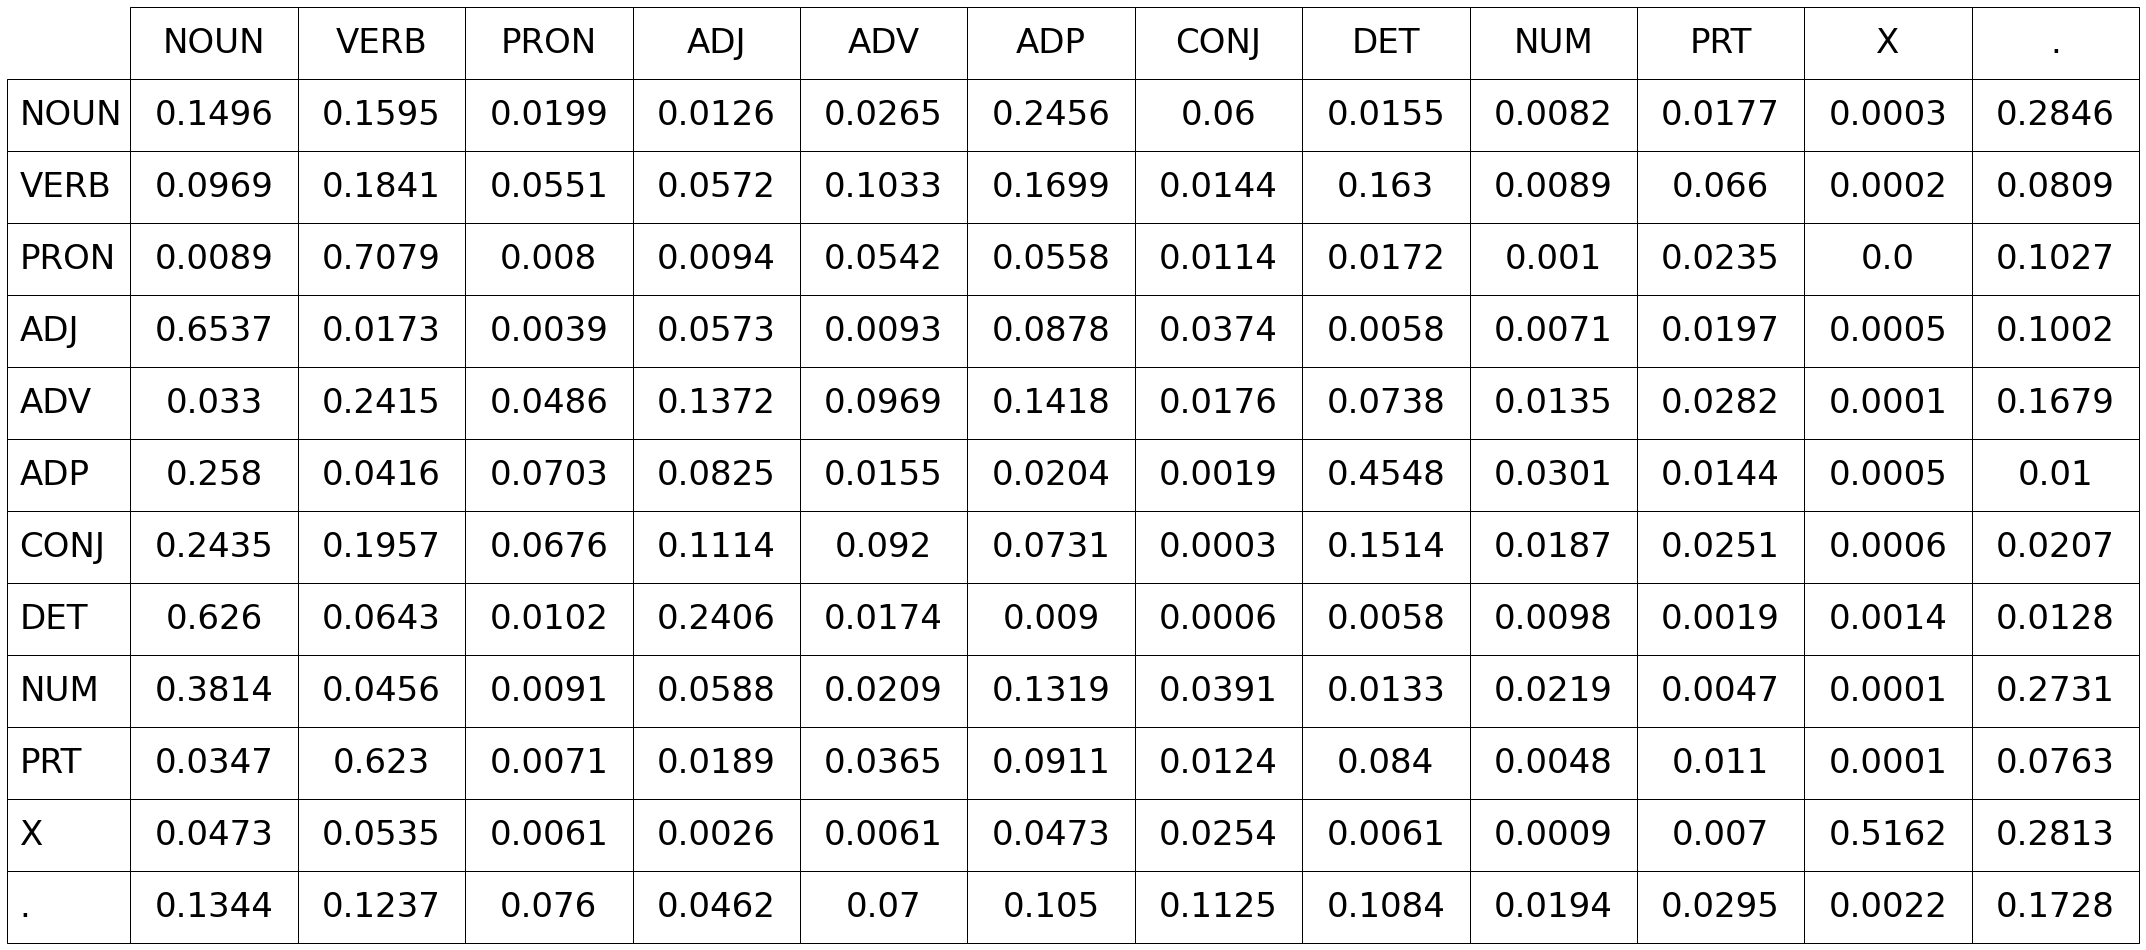

In [ ]:
pl.figure()
tb = pl.table(cellText=transition_matrix, loc=(0,0), cellLoc='center', colLabels = tags, rowLabels = tags)

tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)



### Start Probability

In [ ]:
start_tags = []
for t in train_data:
  start_tags.append(t[0])
start_prob_df = pd.DataFrame(start_tags, columns = ["word", "tag"])
start_prob_df = start_prob_df.groupby(["tag"],as_index=False).size()
start_prob_df = start_prob_df.set_index("tag")

In [ ]:
sum_start_tags = start_prob_df["size"].sum() # 45872

In [ ]:
start_prob_df["size"] = start_prob_df["size"].divide(sum_start_tags)

In [ ]:
start_prob = {}
for index, row in start_prob_df.iterrows():
  start_prob[index] = row["size"]
print(start_prob)

{'.': 0.08879054761074294, 'ADJ': 0.03374607603767004, 'ADP': 0.1240408092082316, 'ADV': 0.08977153819323334, 'CONJ': 0.04841733519358214, 'DET': 0.21422654342518313, 'NOUN': 0.14211283571677713, 'NUM': 0.01711283571677712, 'PRON': 0.16009766306243461, 'PRT': 0.036580048831531216, 'VERB': 0.044602371817230556, 'X': 0.0005013951866062085}


### converting list of data to dictionary

In [ ]:
corpus_dict = {}
id_itr = 1
for d_pt in train_data:
  for word, tag in d_pt:
    try:
      ind = corpus_dict[word]
      continue
    except:
      if tag!='DET' and tag!='.':
        corpus_dict[word] = id_itr
        id_itr+=1

In [ ]:
#print(train_data[0])
#print(corpus_dict)

In [ ]:
print(corpus_dict['said']) ##index

5


### word Embeddings

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# glove_path = "drive/My Drive/Colab Notebooks/glove.6B.300d.txt"

In [ ]:
# f = open(glove_path) 
# embedd_index = {}
# for line in f:
#   val = line.split()
#   word = val[0]
#   coff = np.asarray(val[1:],dtype = 'float')
#   embedd_index[word] = coff
# f.close()

In [ ]:
#embedd_index.most_similar(positive=['university'], topn = 3)

In [ ]:
#print(embedd_index.get('the'))

In [ ]:
# def get_glove_embeddings(corpus_dict):
#   glove_embeddings = np.zeros((len(corpus_dict) + 1, 300))
#   for word,i in corpus_dict.items():
#     glove_emb = embedd_index.get(word)
#     if glove_emb is not None:
#         glove_embeddings[i] = glove_emb
#   return glove_embeddings

In [ ]:
# glove_embeddings = get_glove_embeddings(corpus_dict)

In [ ]:
from gensim import models

In [ ]:
from nltk.data import find
import gensim
nltk.download("word2vec_sample")
word2vec_sample = str(find('models/word2vec_sample/pruned.word2vec.txt'))
model = gensim.models.KeyedVectors.load_word2vec_format(word2vec_sample)

[nltk_data] Downloading package word2vec_sample to /root/nltk_data...
[nltk_data]   Package word2vec_sample is already up-to-date!


In [ ]:
# def getVectorFromW2V(str):
#  if str in word2vec_model:
#   return word2vec_model[str]
#  else:
#   return None
#print(model['rain'])  ##Each word is represented in the space of 300 dimensions:
print(len(model['rain']))

300


In [ ]:
# def get_w2v_embeddings(corpus_dict):
#   w2v_embeddings = np.zeros((len(corpus_dict) + 1, 300))
#   for word,i in corpus_dict.items():
#     w2v_vector = getVectorFromW2V(word)
#   if w2v_vector is not None:
#     w2v_embeddings[i] = w2v_vector
#   return w2v_embeddings

In [ ]:
# def similarity(word):
#   B = word2vec_sample[word]
#   max_cosine = 0
#   max_index = -1
#   index = 0
#   if B is not None:
#     for vec in glove_embeddings:
#       if norm(vec) != 0:
#         cosine_val = np.dot(vec,B)/(norm(vec)*norm(B))
#         if(max_cosine < cosine_val):
#           max_cosine = cosine_val
#           max_index = index   
#       index += 1
#   word = {i for i in corpus_dict if corpus_dict[i]==max_index}
#   return word

In [ ]:
# a = model.most_similar(positive=['channelized'], topn = 50)
# print(a)
# a = word2vec_sample['channelized']
# print(a)

### Finding similar word

In [ ]:
# def similarity(word):
#   B = embedd_index.get(word)
#   max_cosine = 0
#   max_index = -1
#   index = 0
#   if B is not None:
#     for vec in glove_embeddings:
#       if norm(vec) != 0:
#         cosine_val = np.dot(vec,B)/(norm(vec)*norm(B))
#         if(max_cosine < cosine_val):
#           max_cosine = cosine_val
#           max_index = index   
#       index += 1
#   word = {i for i in corpus_dict if corpus_dict[i]==max_index}
#   return word

In [ ]:
def similarity(word):
    try:
        a = model.most_similar(positive=[word], topn = 50)
        for i in range(len(a)):
            try:
                f = a[i][0]
                ff = corpus_dict[f]
                return f
            except:
                continue
    except:
        return ""

In [ ]:
print(similarity('if'))
# if len(similarity('prathyusha'))==0:
#     print("dsas")

unless


### Viterbi Algorithm

In [ ]:
def viterbi(input_sent, trans_prob, em_prob, start_prob, tags):
  
  path_prob = {} # for probability computation
  path_pointer = {} # for pos tags of best path

  # start probability for first word in sentence
  if (input_sent[0], 'NOUN') not in em_prob:
    for s in tags:
        path_prob[s, 0] = 0
        path_pointer[s, 0] = [s]
    path_prob[s,'X'] = 1
  else:
    for s in tags:
        path_prob[s, 0] = start_prob[s] * em_prob[input_sent[0], s]
        path_pointer[s, 0] = [s]
  
  # for words in sentence
  for o in range(1, len(input_sent)):
      obs = input_sent[o]
      for s in tags:
        # calculate path probability of each state for given word
        if (obs, s) not in em_prob:
          flag = 0
          if s == 'X':
            flag = 1
          v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * flag, k) for k in tags]
          k = sorted(v1)[-1][1] # find maximum probability path
          path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * flag
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
        else:
          v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s], k) for k in tags]
          k = sorted(v1)[-1][1]
          path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s]
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
  
  #find max prob path
  last_k = sorted([(path_prob[k, len(input_sent)-1], k) for k in tags])[-1][1]
  pointers = path_pointer[last_k, len(input_sent)-1] # path for max prob
  best_path = [[input_sent[o], pointers[o]] for o in range(len(pointers))]
  return best_path

### Approach 2

In [ ]:
def viterbi_2(input_sent, trans_prob, em_prob, start_prob, tags):
  
  path_prob = {} # for probability computation
  path_pointer = {} # for pos tags of best path
  total_cnt = 0
  vec_cnt = 0
  # start probability for first word in sentence
  if (input_sent[0], 'NOUN') not in em_prob:
    total_cnt += 1
    similar_word = similarity(input_sent[0])
    if len(similar_word) != 0:
        vec_cnt+=1

    for s in tags:
      if len(similar_word)==0:
        path_prob[s, 0] = start_prob[s]*unknown[s][0]
      else:
        path_prob[s, 0] = start_prob[s] * em_prob[similar_word, s]
      path_pointer[s, 0] = [s]
  else:
    for s in tags:
        path_prob[s, 0] = start_prob[s] * em_prob[input_sent[0], s]
        path_pointer[s, 0] = [s]
  
  # for words in sentence
  for o in range(1, len(input_sent)):
      obs = input_sent[o]
      

      if (obs,'NOUN') not in em_prob:
        total_cnt += 1
        similar_obs_word = similarity(input_sent[o])
        if len(similar_obs_word)!=0:
            vec_cnt+=1
            
      for s in tags:
        # calculate path probability of each state for given word
        if (obs, s) not in em_prob:
          if len(similar_obs_word)==0:
             v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * unknown[s][0], k) for k in tags]
             k = sorted(v1)[-1][1] # find maximum probability path
             path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * unknown[s][0]
          else:
            v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * em_prob[similar_obs_word, s], k) for k in tags]
            k = sorted(v1)[-1][1] # find maximum probability path
            path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * em_prob[similar_obs_word, s]
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
        else:
          v1 = [(path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s], k) for k in tags]
          k = sorted(v1)[-1][1]
          path_prob[s, o] = path_prob[k, o - 1] * trans_prob[k, s] * em_prob[obs, s]
          path_pointer[s, o] = path_pointer[k, o - 1].copy()
          path_pointer[s, o].append(s)
  
  #find max prob path
  last_k = sorted([(path_prob[k, len(input_sent)-1], k) for k in tags])[-1][1]
  pointers = path_pointer[last_k, len(input_sent)-1] # path for max prob
  best_path = [[input_sent[o], pointers[o]] for o in range(len(pointers))]
  return [best_path, total_cnt, vec_cnt]

### Inference

In [ ]:
def test(test_str, trans_prob, em_prob, start_prob, tags):
  test_list = test_str.lower().split()
  return viterbi_2(test_list, trans_prob, em_prob, start_prob, tags)
  

In [ ]:
test_str = "the long and lonely rd to mumbai ."
trans_prob_test = ti
em_prob_test = e
start_prob_test = start_prob
tags_test = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
print(test_str)
a = test(test_str, trans_prob_test, em_prob_test, start_prob_test, tags_test)
#u,t,d = test(test_str, trans_prob_test, em_prob_test, start_prob_test, tags_test)
print(a[0])
#print(a[1]) #total unknown words in sentence
#print(a[2]) #totl al smilar vectors for unknown words in snetence

the long and lonely rd to mumbai .
[['the', 'DET'], ['long', 'ADJ'], ['and', 'CONJ'], ['lonely', 'ADJ'], ['rd', 'NOUN'], ['to', 'ADP'], ['mumbai', 'NOUN'], ['.', '.']]


In [ ]:
test_results = []
index = 0
total_count = 0
unknown_similar_count =0
for t_data in test_data:
  try:
    sentence = [j[0] for j in t_data]
    res = viterbi_2(sentence, ti, e, start_prob, tags)
    unknown_similar_count += res[2]
    total_count += res[1]
    pred = res[0]
    test_results.append([t_data, pred])
  except:
    continue
  index += 1
  if index % 100 == 0:
    print(index)
print("unknown_with_similar",unknown_similar_count)
print("total_unknown",total_count)


100
200
300
400
500
600
700
800
900
1000
1100
1200
1300
1400
1500
1600
1700
1800
1900
2000
2100
2200
2300
2400
2500
2600
2700
2800
2900
3000
3100
3200
3300
3400
3500
3600
3700
3800
3900
4000
4100
4200
4300
4400
4500
4600
4700
4800
4900
5000
5100
5200
5300
5400
5500
5600
5700
5800
5900
6000
6100
6200
6300
6400
6500
6600
6700
6800
6900
7000
7100
7200
7300
7400
7500
7600
7700
7800
7900
8000
8100
8200
8300
8400
8500
8600
8700
8800
8900
9000
9100
9200
9300
9400
9500
9600
9700
9800
9900
10000
10100
10200
10300
10400
10500
10600
10700
10800
10900
11000
11100
11200
11300
11400
unknown_with_similar 2419
total_unknown 5121


In [ ]:
print(len(test_data), len(test_results)) #11468 11468
#print(test_data[0])
print([j[0] for j in test_data[4]])
print(test_results[4][0]) #test_data
print(test_results[4][1]) #pred_data


11468 11468
['wards', 'protected']
[['wards', 'NOUN'], ['protected', 'VERB']]
[['wards', 'NOUN'], ['protected', 'VERB']]


### Examples of sentences with actual tag and predicted tag

In [ ]:
def tags(index):
  labels = [j[0] for j in test_results[index][0]]
  test_data_tag = [j[1] for j in test_results[index][0]]
  pred_data_tag = [j[1] for j in test_results[index][1]]
  data_tag = [test_data_tag,pred_data_tag]
  return [labels,data_tag]

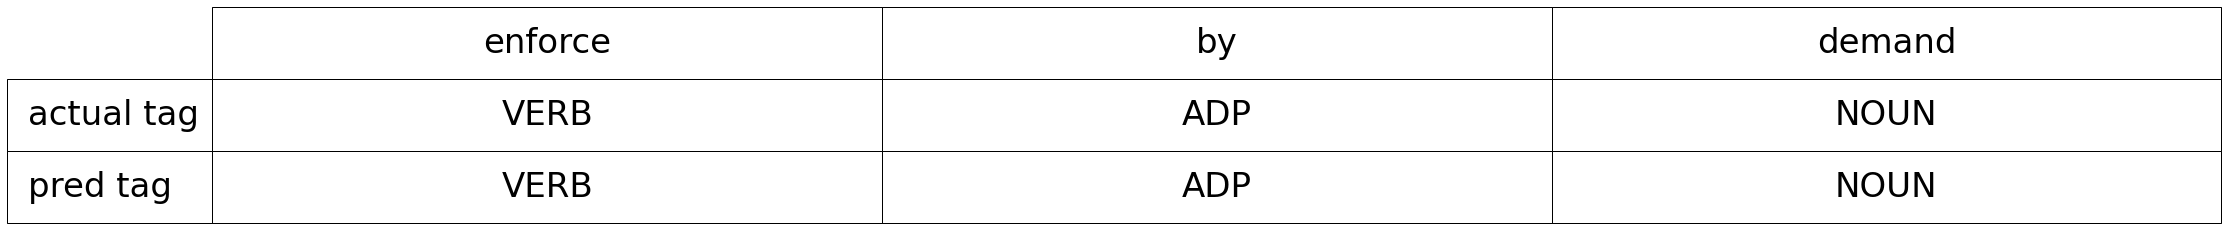

In [ ]:
row_labels = ['actual tag','pred tag']
[labels,data_tag] = tags(80)
pl.figure()
tb = pl.table(cellText=data_tag, loc=(0,0), colLabels = labels, rowLabels = row_labels, cellLoc='center')
tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)

### Classify Data w.r.t Each Tag

In [ ]:
def classify(test_results,tag):
       cpred_data=[]
       ctest_data=[]
       for t_data in test_results:
         for j in t_data[0]:
              if j[1]==tag:
                    cpred_data.append([j[0],j[1],1])
              else:
                    cpred_data.append([j[0],j[1],0])
         for j in t_data[1]:
              if j[1]==tag:
                    ctest_data.append([j[0],j[1],1])
              else:
                    ctest_data.append([j[0],j[1],0])
       class_results = []
       class_results.append([cpred_data,ctest_data])
       return class_results 

In [ ]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']

In [ ]:
classify_data = []
for tag in tags:
    classify_data.append([tag,classify(test_results,tag)])

# print(classify_data[11][1][0][1]) #pred_data_classify
#print(len(classify_data[11][1][0]))

### Calculations of TP, FP, TN, FN for each tag

In [ ]:
def measure(tag,results):
    TP = 0
    FP = 0
    TN = 0
    FN = 0
    for i in range(len(results[0])): 
        if results[1][i][2]==results[0][i][2]==1:
           TP += 1
        if results[0][i][2]==1 and results[1][i][2]!=results[0][i][2]:
           FP += 1
        if results[1][i][2]==results[0][i][2]==0:
           TN += 1
        if results[0][i][2]==0 and results[1][i][2]!=results[0][i][2]:
           FN += 1
    return[tag,TP, FP, TN, FN]

In [ ]:
count = []
i=0
for result in classify_data:
        count.append(measure(tags[i],result[1][0]))
        i+=1
#print(count)
table = pd.DataFrame(count, columns = ["tag","TP", "FP","TN","FN"])
print(table)

     tag     TP    FP      TN    FN
0   NOUN  52867  2001  173004  2241
1   VERB  34577  1402  193240   894
2   PRON   9423   137  220289   264
3    ADJ  15148  1526  212264  1175
4    ADV  10108  1099  217834  1072
5    ADP  27667   881  200355  1210
6   CONJ   7504    53  222506    50
7    DET  26891   355  202221   646
8    NUM   2689   220  227127    77
9    PRT   5325   578  223660   550
10     X    123   121  229782    87
11     .  29411     7  200581   114


### Precision, Recall, F1 Score for each tag

In [ ]:
def metrics(tag,TP,FN,FP):
  precision = TP/(TP+FP)
  recall = TP/(TP+FN)
  F1 = 2 * precision * recall/(recall + precision)
  F2 = 5 * precision * recall/(recall + (4 * precision))
  F05 = 1.25 * precision * recall/(recall + (0.25 * precision))
  return[tag,TP,FN,FP,precision,recall,F1,F2,F05]

In [ ]:
metric = []
i=0
for data in count:
  TP = data[1]
  FN = data[4]
  FP = data[2]
  metric.append(metrics(tags[i],TP,FN,FP))
  i+=1
print(metric)
metrics_table = pd.DataFrame(metric, columns = ["tag","TP","FN","FP","precision", "recall","F1-score","F2-score","F0.5-score"])
print(metrics_table)

[['NOUN', 52867, 2241, 2001, 0.9635306553911205, 0.9593343979095594, 0.9614279479159089, 0.9601707228478024, 0.9626884696627577], ['VERB', 34577, 894, 1402, 0.9610328247032991, 0.9747963124806179, 0.9678656403079076, 0.9720121666676036, 0.9637543411729945], ['PRON', 9423, 264, 137, 0.9856694560669456, 0.9727469804893156, 0.9791655842468956, 0.975304297424857, 0.9830575667160472], ['ADJ', 15148, 1175, 1526, 0.90848026868178, 0.9280156833915334, 0.91814407370367, 0.9240416758168022, 0.9123212758525158], ['ADV', 10108, 1072, 1099, 0.9019362898188632, 0.9041144901610018, 0.9030240764729529, 0.9036780088329429, 0.9023710898443078], ['ADP', 27667, 1210, 881, 0.9691396945495306, 0.9580981403885445, 0.9635872877666521, 0.9602862775587271, 0.9669110708818821], ['CONJ', 7504, 50, 53, 0.9929866349080323, 0.9933809902038655, 0.9931837734100987, 0.9933020940883699, 0.9930654809168387], ['DET', 26891, 646, 355, 0.9869705644865301, 0.9765406543922722, 0.9817279082927186, 0.9786089640013393, 0.9848667

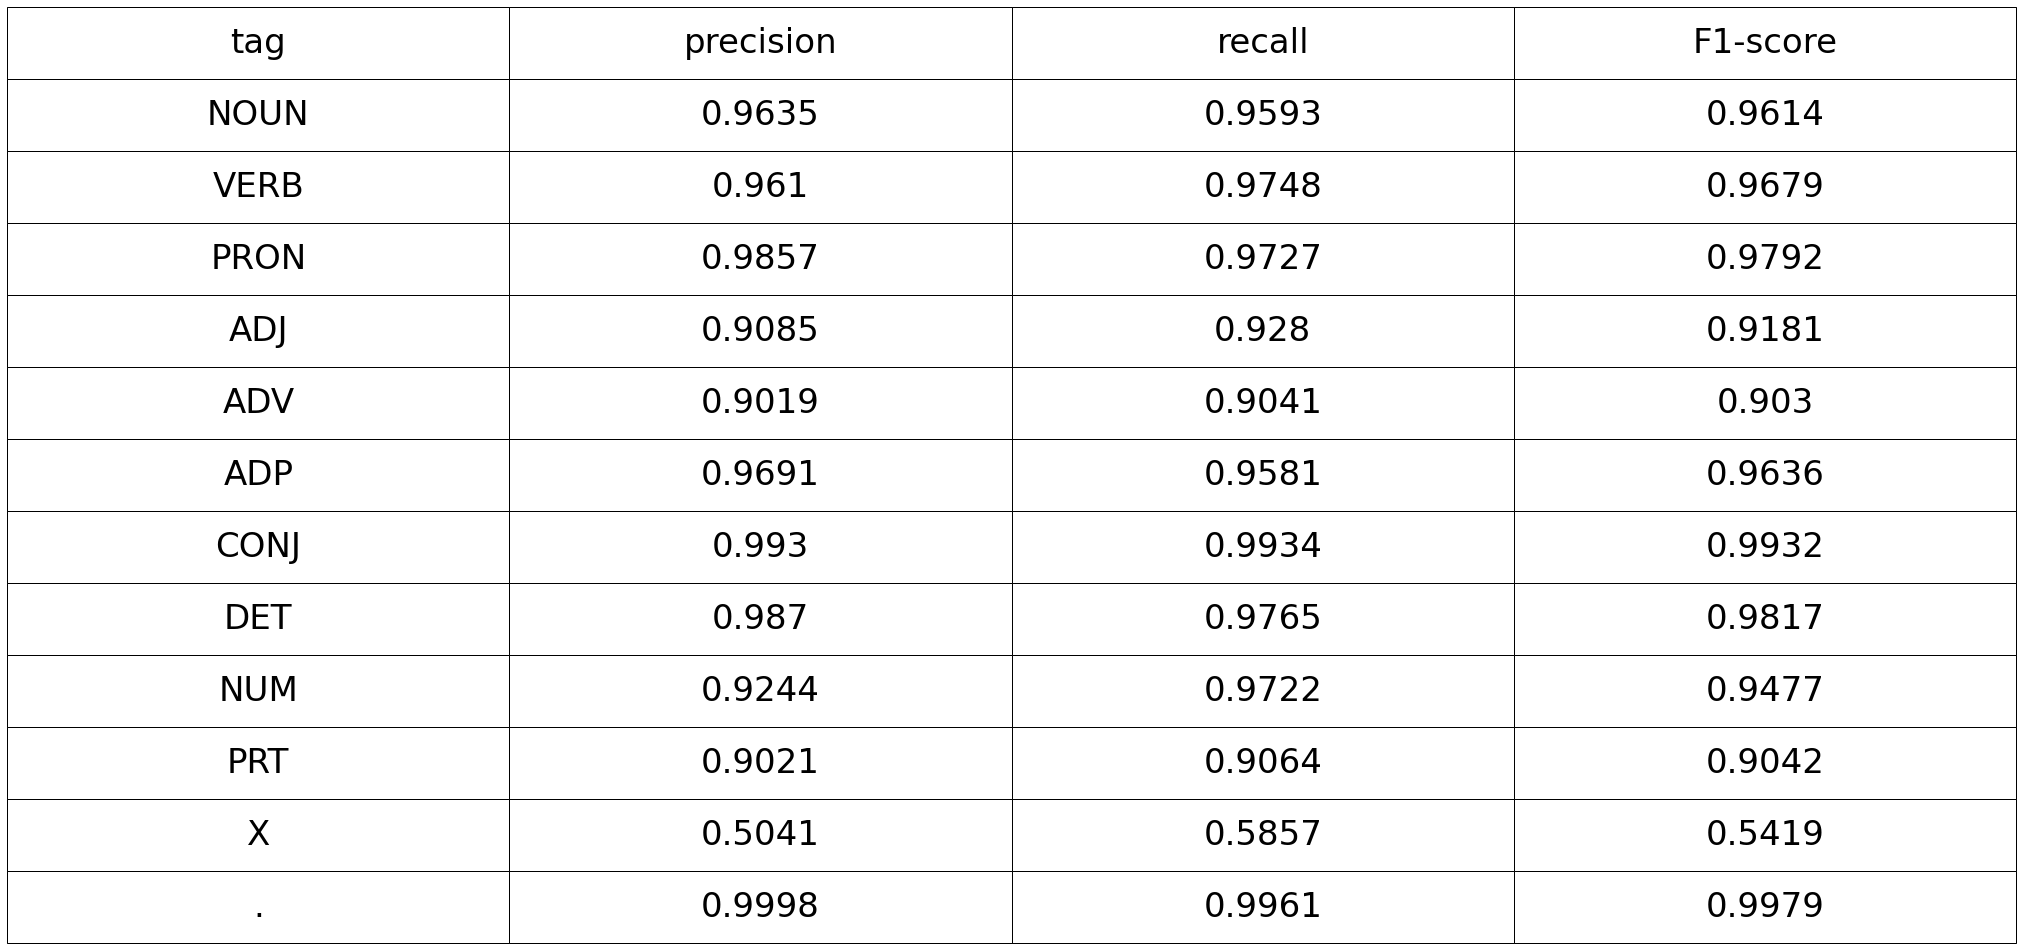

In [ ]:
labels = ["tag","precision", "recall","F1-score"]
pl.figure()

metric_show = metric
met = []
mp = 0
mr = 0
mf = 0
for m in metric_show:
  mp = round(m[4], 4)
  mr = round(m[5], 4)
  mf = round(m[6], 4)
  met.append([m[0],mp,mr,mf])


# metric_np = np.around(metric_np, decimals = 4)
tb = pl.table(cellText=met, loc=(0,0), colLabels = labels, cellLoc='center')

tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)
pl.savefig('myimage.png') 

### Overall Performance in terms of precision, recall, F1 score, F2 score, F0.5 score

### Weighted Averages

In [ ]:
prec_add=0
reca_add=0
F1_add=0
F2_add=0
F05_add=0
total=0
for metric_each in metric:
  prec_add += metric_each[4]*(metric_each[1]+metric_each[2])
  reca_add += metric_each[5]*(metric_each[1]+metric_each[2])
  F1_add += metric_each[6]*(metric_each[1]+metric_each[2])
  F2_add += metric_each[7]*(metric_each[1]+metric_each[2])
  F05_add += metric_each[8]*(metric_each[1]+metric_each[2])
  total += metric_each[1]+metric_each[2]

precision = prec_add/total
recall = reca_add/total
F1 = F1_add/total
F2 = F2_add/total
F05 = F05_add/total
print("precision: ",precision)
print("recall: ",recall)
print("F1: ",F1)
print("F2: ",F2)
print("F0.5: ",F05)

precision:  0.9638458576780979
recall:  0.9635831091681044
F1:  0.9636787517115832
F2:  0.9636126055476713
F0.5:  0.9637706146647637


### Accumulated Performance

In [ ]:
TP=0
FN=0
FP=0
for data in count:
      TP += data[1]
      FN += data[4]
      FP += data[2]
precision = TP/(TP+FP)
recall = TP/(TP+FN)
F1 = 2 * precision * recall/(recall + precision)
F2 = 5 * precision * recall/(recall + (4 * precision))
F05 = 1.25 * precision * recall/(recall + (0.25 * precision))
print("precision: ",precision)
print("recall: ",recall)
print("F1: ",F1)
print("F2: ",F2)
print("F0.5: ",F05)

precision:  0.9635831091681044
recall:  0.9635831091681044
F1:  0.9635831091681044
F2:  0.9635831091681044
F0.5:  0.9635831091681044


### Confusion matrix

In [ ]:
def build_confusion(test_results, tags):
  confusion_mat = {}
  for tag in tags:
    for t_data in test_results:
      for j in range(len(t_data[1])):
        if tag == t_data[0][j][1]:
          if (tag, t_data[1][j][1]) not in confusion_mat:
            confusion_mat[tag, t_data[1][j][1]] = 1
          else:
            confusion_mat[tag, t_data[1][j][1]] += 1
  return confusion_mat

In [ ]:
tags = ['NOUN', 'VERB', 'PRON', 'ADJ', 'ADV', 'ADP', 'CONJ', 'DET', 'NUM', 'PRT', 'X', '.']
indices_map = {'NOUN': 0,'VERB':1, 'PRON' : 2, 'ADJ' : 3, 'ADV': 4, 'ADP' : 5, 'CONJ': 6, 'DET': 7, 'NUM': 8, 'PRT' :9, 'X':10, '.':11}
confusion_matrix = build_confusion(test_results,tags)

In [ ]:
# print(confusion_matrix)

In [ ]:
# for tag in confusion_matrix:
#   print("Tag: ", tag, confusion_matrix[tag])
  # for vals in tag[0]:
  #   print(vals, tag[0][vals])

In [ ]:
nx = 12
ny = 12
data_confusion = np.zeros((nx,ny))

for tag_data in confusion_matrix:
    data_confusion[indices_map[tag_data[0]]][indices_map[tag_data[1]]] = confusion_matrix[tag_data]

data_confusion = np.array([1.0*row/row.sum() for row in data_confusion])
# data_confusion = np.array([row for row in data_confusion])
data_confusion = np.around(data_confusion, decimals = 4)

In [ ]:
print(data_confusion)

[[9.635e-01 1.360e-02 1.000e-04 1.030e-02 7.000e-04 2.800e-03 0.000e+00
  5.400e-03 1.300e-03 3.000e-04 8.000e-04 1.200e-03]
 [3.320e-02 9.610e-01 0.000e+00 3.200e-03 3.000e-04 1.300e-03 0.000e+00
  4.000e-04 0.000e+00 1.000e-04 3.000e-04 2.000e-04]
 [6.000e-04 0.000e+00 9.857e-01 0.000e+00 2.000e-04 8.200e-03 0.000e+00
  5.300e-03 0.000e+00 0.000e+00 0.000e+00 0.000e+00]
 [4.060e-02 6.400e-03 0.000e+00 9.085e-01 3.060e-02 1.400e-03 0.000e+00
  8.600e-03 2.000e-04 2.700e-03 4.000e-04 5.000e-04]
 [5.500e-03 1.000e-03 1.000e-04 4.240e-02 9.019e-01 3.010e-02 1.900e-03
  2.600e-03 0.000e+00 1.440e-02 1.000e-04 1.000e-04]
 [5.000e-04 5.000e-04 2.200e-03 4.000e-04 1.330e-02 9.691e-01 8.000e-04
  1.400e-03 0.000e+00 1.140e-02 3.000e-04 2.000e-04]
 [1.000e-04 0.000e+00 0.000e+00 0.000e+00 3.800e-03 5.000e-04 9.930e-01
  2.000e-03 0.000e+00 0.000e+00 5.000e-04 0.000e+00]
 [0.000e+00 0.000e+00 7.000e-03 0.000e+00 1.100e-03 4.600e-03 2.000e-04
  9.870e-01 0.000e+00 0.000e+00 0.000e+00 0.000e+00]


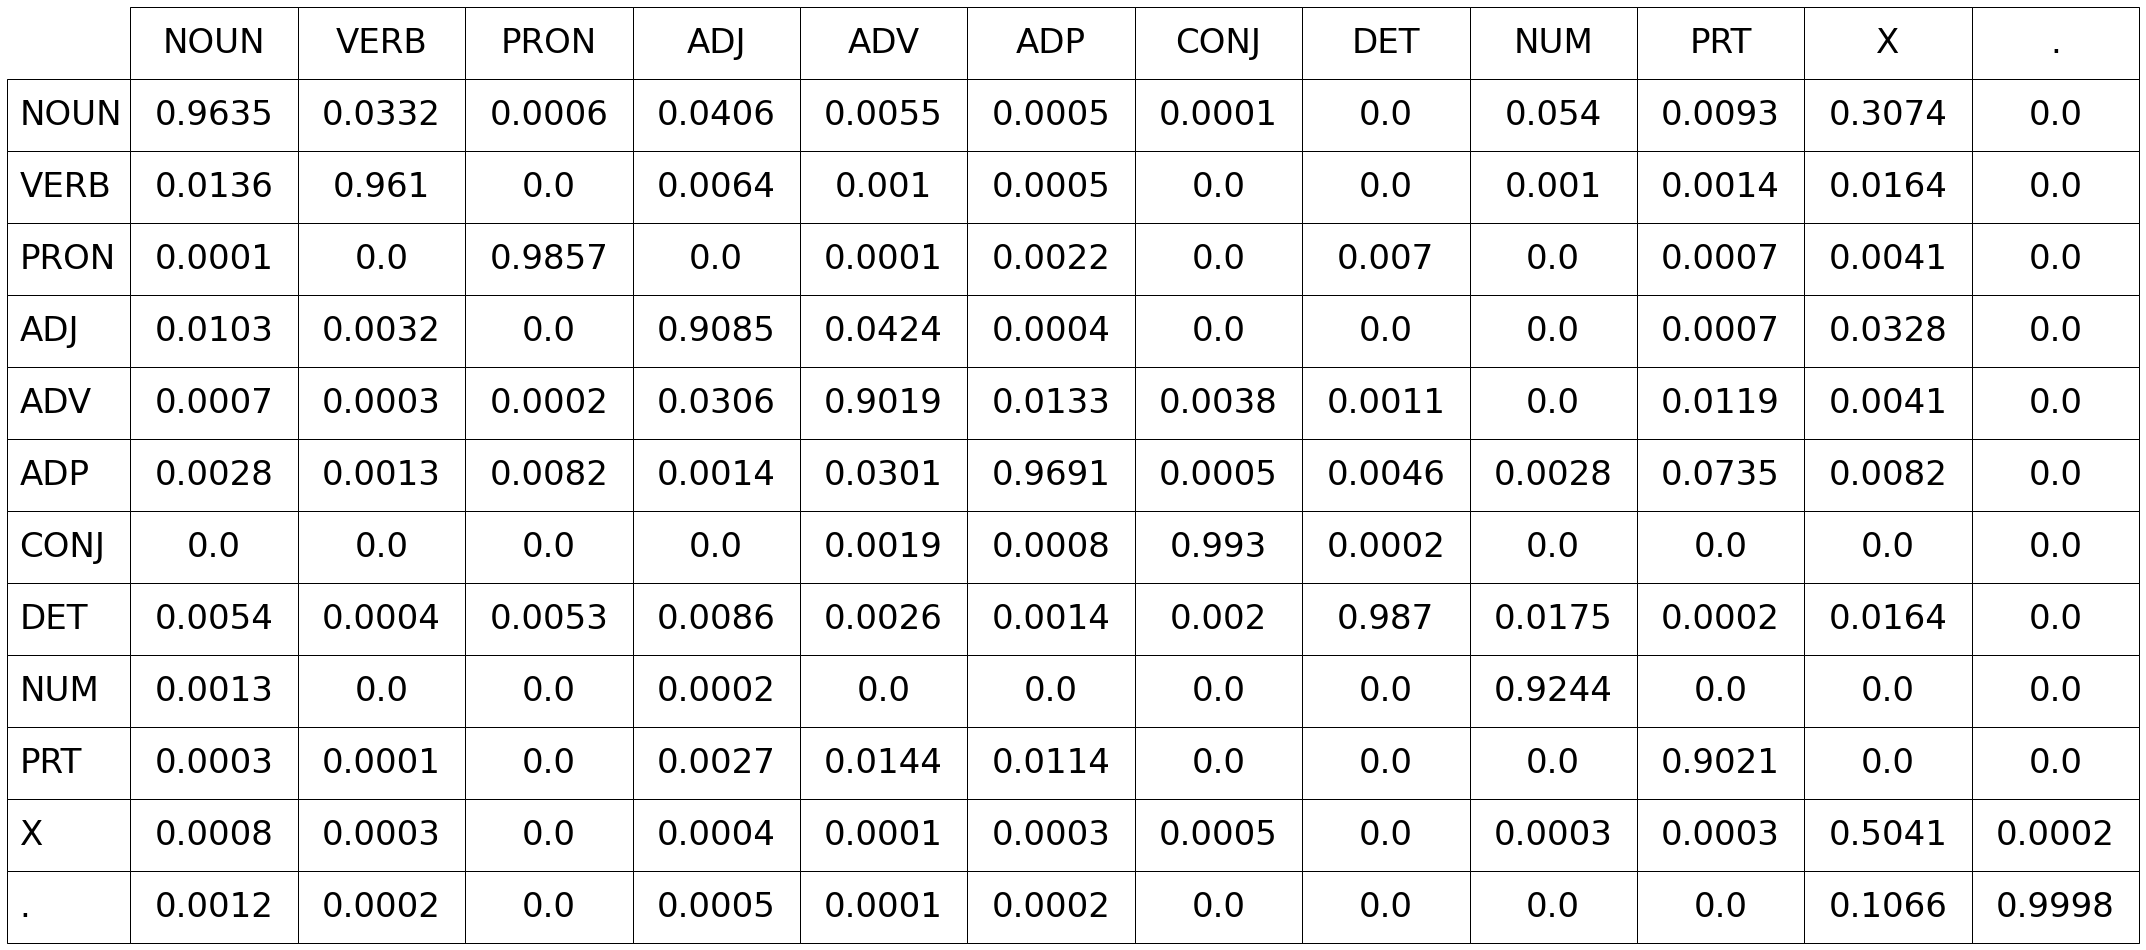

In [ ]:
pl.figure()
tb = pl.table(cellText=data_confusion.T, loc=(0,0), cellLoc='center', colLabels = tags, rowLabels = tags)

tb.set_fontsize(34)
pl.axis("off")
tb.scale(6, 6)


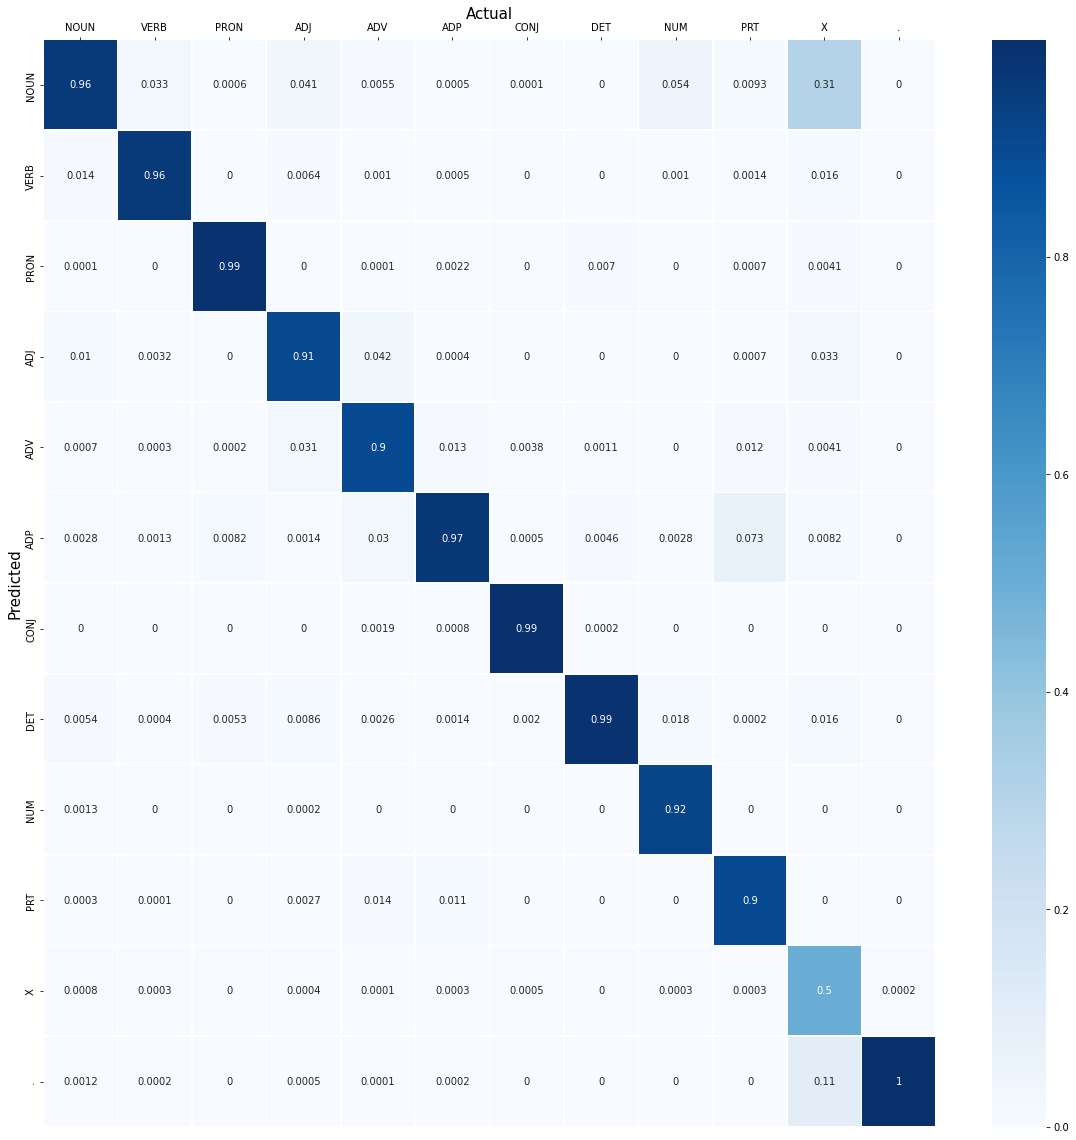

<Figure size 432x288 with 0 Axes>

In [ ]:

pl.figure(figsize = (20,20))
ax = sns.heatmap(data_confusion.T, annot=True, cmap='Blues', linewidth = 0.5, xticklabels = tags, yticklabels = tags)
ax.set_xlabel('Actual', fontsize=15)
ax.set_ylabel('Predicted', fontsize=15)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
pl.show()
pl.savefig('conf.png')